正在下载Fashion-MNIST数据集...
训练集大小： (60000, 784)
测试集大小： (10000, 784)

========== 实验结果 ==========
Accuracy  : 0.8541
Precision : 0.8575
Recall    : 0.8541
F1-score  : 0.8539
训练时间   : 0.5602 秒


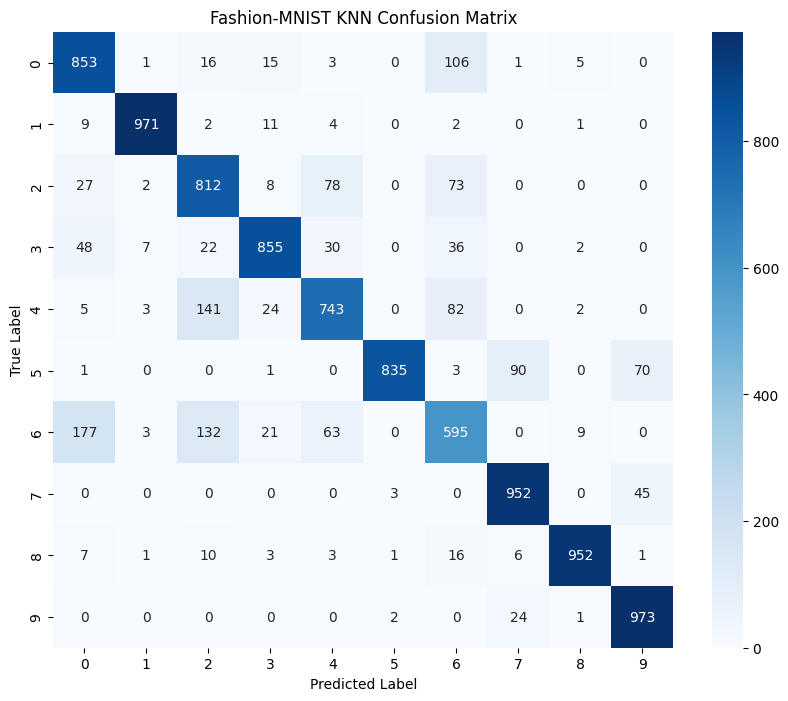

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import time

# ==========================
# 1. 下载 Fashion MNIST
# ==========================
print("正在下载Fashion-MNIST数据集...")

X, y = fetch_openml(
    'Fashion-MNIST',
    version=1,
    return_X_y=True,
    as_frame=False
)

# ==========================
# 2. 数据归一化
# ==========================
X = X / 255.0

# ==========================
# 3. 划分训练集和测试集
# ==========================
X_train = X[:60000]
X_test = X[60000:]

y_train = y[:60000]
y_test = y[60000:]

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

# ==========================
# 4. 创建KNN模型
# ==========================
model = KNeighborsClassifier(n_neighbors=3)

# ==========================
# 5. 记录训练时间
# ==========================
start_time = time.time()

model.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

# ==========================
# 6. 预测
# ==========================
y_pred = model.predict(X_test)

# ==========================
# 7. 计算评价指标
# ==========================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

# ==========================
# 8. 输出结果
# ==========================
print("\n========== 实验结果 ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"训练时间   : {train_time:.4f} 秒")

# ==========================
# 9. 混淆矩阵
# ==========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Fashion-MNIST KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()